# 15-1 · Outliers en Regresión

Un **outlier** es una observación cuyo valor de respuesta ($y$) está lejos de lo que el modelo predice. Se detectan con los **residuos estandarizados**.

En este notebook:
1. Entendemos qué es un outlier en contexto de regresión
2. Aprendemos a detectarlos con residuos estandarizados
3. Visualizamos su impacto
4. Exploramos qué hacer cuando los encontramos

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("../data/housing.csv")
print(f"Filas: {len(df)}")
df.head(3)

Filas: 100


,id,square_meters,age,price,bedrooms,bathrooms,floor,distance_to_center_km,has_garage,build_quality,property_type,neighborhood
0,1,152,33,338200,4,2,1,4.3,1,10,Single Family,El Prado
1,2,142,24,266900,4,3,8,6.6,1,3,Single Family,Las Flores
2,3,64,11,170800,2,1,1,14.0,1,6,Apartment,El Mirador


In [2]:
# --- Modelo base ---
predictors = [
    "square_meters",
    "bedrooms",
    "bathrooms",
    "build_quality",
    "age",
    "distance_to_center_km",
    "has_garage",
]

X = df[predictors].to_numpy()
y = df["price"].to_numpy()
n, p = X.shape

X_const = sm.add_constant(X)
ols = sm.OLS(y, X_const).fit()
influence = ols.get_influence()

y_pred = ols.fittedvalues
e = ols.resid
std_resid = influence.resid_studentized_internal

print(f"R² = {ols.rsquared:.4f}")
print(f"n = {n}, p = {p}")

R² = 0.8713
n = 100, p = 7


## 1 · ¿Qué es un outlier en regresión?

En regresión, un outlier **no** es simplemente un valor extremo de $X$ o $Y$. Es una observación cuyo **residuo** es inusualmente grande: el modelo se equivoca mucho en esa observación.

> 👈 Una casa de $500,000 no es outlier si el modelo predice $490,000. Pero una casa de $200,000 cuando el modelo predice $350,000 **sí lo es**.

## 2 · Residuos Estandarizados (*Standardized Residuals*)

Los residuos crudos ($e_i = y_i - \hat{y}_i$) no son directamente comparables porque cada observación tiene distinto **leverage**. Por eso usamos residuos estandarizados:

$$r_i = \frac{e_i}{s \cdot \sqrt{1 - h_{ii}}}$$

| Umbral | Interpretación |
|--------|----------------|
| $|r_i| > 2$ | ⚠️ Sospechoso |
| $|r_i| > 3$ | 🚨 Outlier fuerte |

Con una distribución normal, esperamos ~5% de observaciones con $|r| > 2$ por azar.

In [6]:
# Residuos estandarizados ya calculados por statsmodels
print("Estadísticas de los residuos estandarizados:")
print(f"  Media:    {std_resid.mean():.4f}")
print(f"  Std:      {std_resid.std():.4f}")
print(f"  Min:      {std_resid.min():.2f}")
print(f"  Max:      {std_resid.max():.2f}")
print(f"\nEsperados con |r| > 2 por azar (~5%): {n * 0.05:.0f}")
print(f"Observados con |r| > 2: {np.sum(np.abs(std_resid) > 2)}")

Estadísticas de los residuos estandarizados:
  Media:    0.0006
  Std:      0.9985
  Min:      -1.98
  Max:      2.64

Esperados con |r| > 2 por azar (~5%): 5
Observados con |r| > 2: 2


## 3 · Detectar Outliers

In [3]:
outlier_mask = np.abs(std_resid) > 2
n_outliers = np.sum(outlier_mask)

print(f"Outliers (|r| > 2): {n_outliers} de {n} ({100 * n_outliers / n:.1f}%)\n")

outlier_df = pd.DataFrame(
    {
        "price": y[outlier_mask],
        "predicted": y_pred[outlier_mask].round(0),
        "residual": e[outlier_mask].round(0),
        "std_resid": std_resid[outlier_mask].round(2),
        "severity": [
            "🚨 |r|>3" if abs(r) > 3 else "⚠️ |r|>2" for r in std_resid[outlier_mask]
        ],
    },
    index=np.where(outlier_mask)[0],
)
outlier_df.index.name = "obs"
outlier_df

Outliers (|r| > 2): 2 de 100 (2.0%)



,price,predicted,residual,std_resid,severity
obs,,,,,
9,282500,223883.0,58617.0,2.64,⚠️ |r|>2
12,343800,289334.0,54466.0,2.53,⚠️ |r|>2


## 4 · Visualización

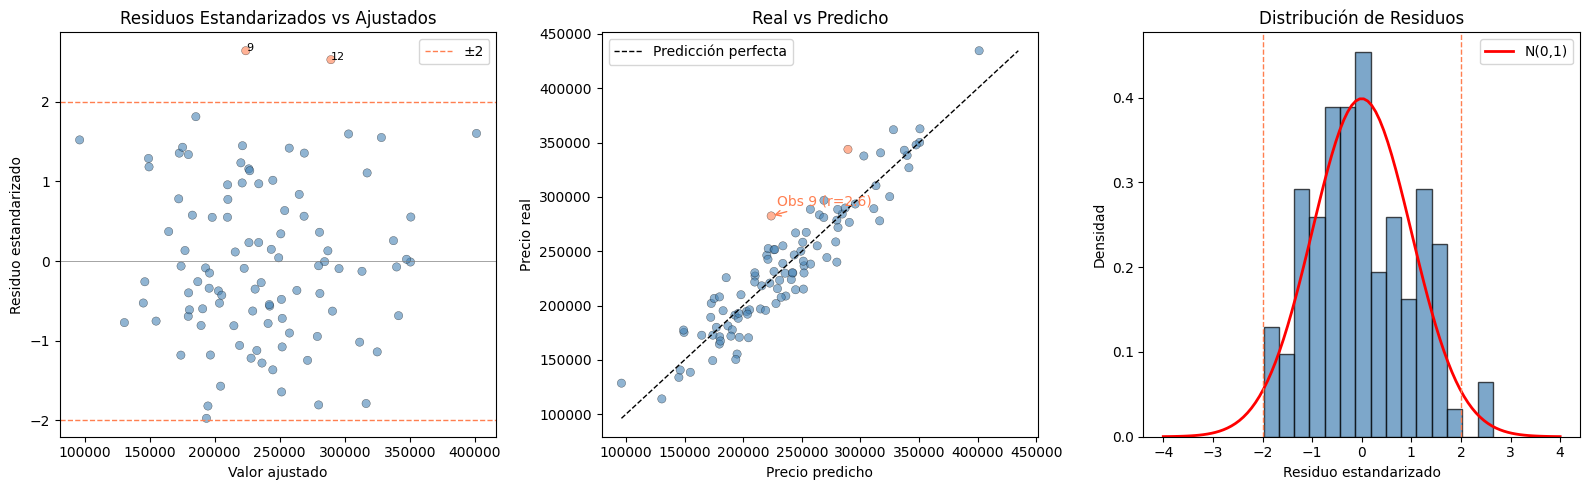

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- 1. Std Residuals vs Fitted ---
ax = axes[0]
colors = ["coral" if abs(r) > 2 else "steelblue" for r in std_resid]
ax.scatter(y_pred, std_resid, c=colors, alpha=0.6, edgecolors="k", linewidth=0.3)
ax.axhline(y=0, color="gray", linestyle="-", linewidth=0.5)
ax.axhline(y=2, color="coral", linestyle="--", linewidth=1, label="±2")
ax.axhline(y=-2, color="coral", linestyle="--", linewidth=1)
for i in np.where(outlier_mask)[0]:
    ax.annotate(str(i), (y_pred[i], std_resid[i]), fontsize=8, ha="left")
ax.set_xlabel("Valor ajustado")
ax.set_ylabel("Residuo estandarizado")
ax.set_title("Residuos Estandarizados vs Ajustados")
ax.legend()

# --- 2. Real vs Predicted ---
ax = axes[1]
colors2 = ["coral" if m else "steelblue" for m in outlier_mask]
ax.scatter(y_pred, y, c=colors2, alpha=0.6, edgecolors="k", linewidth=0.3)
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
ax.plot(lims, lims, "k--", linewidth=1, label="Predicción perfecta")
worst = np.argmax(np.abs(std_resid))
ax.annotate(
    f"Obs {worst} (r={std_resid[worst]:.1f})",
    xy=(y_pred[worst], y[worst]),
    xytext=(y_pred[worst] + 5000, y[worst] + 10000),
    arrowprops=dict(arrowstyle="->", color="coral"),
    fontsize=10,
    color="coral",
)
ax.set_xlabel("Precio predicho")
ax.set_ylabel("Precio real")
ax.set_title("Real vs Predicho")
ax.legend()

# --- 3. Histograma ---
ax = axes[2]
ax.hist(
    std_resid, bins=15, color="steelblue", edgecolor="black", density=True, alpha=0.7
)
x_norm = np.linspace(-4, 4, 100)
ax.plot(x_norm, stats.norm.pdf(x_norm), "r-", linewidth=2, label="N(0,1)")
ax.axvline(x=2, color="coral", linestyle="--", linewidth=1)
ax.axvline(x=-2, color="coral", linestyle="--", linewidth=1)
ax.set_xlabel("Residuo estandarizado")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de Residuos")
ax.legend()

plt.tight_layout()
plt.show()

## 5 · ¿Qué impacto tiene un outlier en el modelo?

Veamos qué pasa si eliminamos el outlier más extremo y reajustamos:

In [5]:
worst_idx = np.argmax(np.abs(std_resid))
print(f"Outlier más extremo: observación {worst_idx}")
print(f"  Price real: ${y[worst_idx]:,.0f}")
print(f"  Price predicho: ${y_pred[worst_idx]:,.0f}")
print(f"  Residuo estandarizado: {std_resid[worst_idx]:.2f}\n")

# Reajustar sin el outlier
mask_no_outlier = np.ones(n, dtype=bool)
mask_no_outlier[worst_idx] = False

ols_clean = sm.OLS(y[mask_no_outlier], X_const[mask_no_outlier]).fit()

# Comparar coeficientes
print(f"{'Predictor':>25s} {'Con outlier':>12s} {'Sin outlier':>12s} {'Cambio %':>10s}")
print("-" * 62)
names = ["intercepto"] + predictors
for name, c1, c2 in zip(names, ols.params, ols_clean.params):
    pct = 100 * (c2 - c1) / abs(c1) if abs(c1) > 0.01 else 0
    print(f"{name:>25s} {c1:>12,.1f} {c2:>12,.1f} {pct:>9.1f}%")

print(f"\n{'R²':>25s} {ols.rsquared:>12.4f} {ols_clean.rsquared:>12.4f}")

Outlier más extremo: observación 9
  Price real: $282,500
  Price predicho: $223,883
  Residuo estandarizado: 2.64

                Predictor  Con outlier  Sin outlier   Cambio %
--------------------------------------------------------------
               intercepto     60,238.7     60,566.4       0.5%
            square_meters        978.4        993.7       1.6%
                 bedrooms     -4,494.6     -6,303.2     -40.2%
                bathrooms      8,200.6      9,927.1      21.1%
            build_quality     13,552.7     13,709.6       1.2%
                      age       -577.9       -594.3      -2.8%
    distance_to_center_km     -1,675.5     -1,680.2      -0.3%
               has_garage     23,169.5     22,503.5      -2.9%

                       R²       0.8713       0.8803


## 6 · ¿Qué hacer con los outliers?

| Situación | Acción |
|-----------|--------|
| Error de datos (typo, sensor malo) | ✅ Corregir o eliminar |
| Observación genuinamente inusual | ⚠️ Investigar, reportar modelo con y sin ella |
| Muchos outliers (>5%) | 🚨 El modelo puede estar mal especificado |

> 👈 **Nunca elimines outliers automáticamente.** Primero investiga por qué el modelo falla en esa observación. Puede revelar un predictor faltante o una relación no lineal.

## 7 · Residuos Studentizados Externos (*Externally Studentized*)

Una variante más robusta: calcular el residuo estandarizado usando un modelo ajustado **sin** la observación $i$. Esto evita que el propio outlier infle la estimación de $s$.

$$t_i = \frac{e_i}{s_{(i)} \cdot \sqrt{1 - h_{ii}}}$$

Sigue una distribución $t$ con $n - p - 2$ grados de libertad.

In [6]:
# Residuos studentizados externos (leave-one-out)
ext_resid = influence.resid_studentized_external

# Comparar interno vs externo para los outliers
print(f"{'Obs':>5} {'Interno':>10} {'Externo':>10} {'Diferencia':>10}")
print("-" * 38)
for i in np.where(outlier_mask)[0]:
    diff = ext_resid[i] - std_resid[i]
    print(f"{i:>5d} {std_resid[i]:>10.2f} {ext_resid[i]:>10.2f} {diff:>10.2f}")

print("\n👈 Si el externo es mucho mayor que el interno,")
print("   el outlier está inflando la estimación de varianza del modelo.")

  Obs    Interno    Externo Diferencia
--------------------------------------
    9       2.64       2.74       0.09
   12       2.53       2.61       0.08

👈 Si el externo es mucho mayor que el interno,
   el outlier está inflando la estimación de varianza del modelo.


## 8 · Resumen

| Concepto | Detalle |
|----------|--------|
| **Outlier en regresión** | Observación con residuo inusualmente grande |
| **Detección** | Residuos estandarizados: $|r_i| > 2$ (sospechoso), $> 3$ (fuerte) |
| **Residuo interno** | `influence.resid_studentized_internal` — usa todos los datos |
| **Residuo externo** | `influence.resid_studentized_external` — leave-one-out, más robusto |
| **Acción** | Investigar, no eliminar ciegamente |